<div style="text-align:center;padding:14px 0 6px 0;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#b0b0b0,#8e24aa,#7b1fa2);background-size:300% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:40px;font-weight:900;animation:tp4Flow 7s ease-in-out infinite;padding:10px 26px;border-bottom:3px solid #8e24aa;animation:tp4Flow 6s ease-in-out infinite,tp4Glow 3s ease-in-out infinite;">PARTIE 2 · Frontières de Décision</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="font-family:'Segoe UI',system-ui,sans-serif;max-width:960px;margin:auto;">
<span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#b0b0b0,#8e24aa,#7b1fa2);background-size:300% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:2.3rem;font-weight:900;animation:tp4Flow 7s ease-in-out infinite;padding:6px 0;border-bottom:3px solid #8e24aa;">TP4 : Classification Robuste — Partie 2</span>
<p style="font-size:1.08rem;margin:12px 0 14px 0;opacity:.9;">Phase II : classification par frontières de décision et non-linéaire — Arbres de décision, Boosting, SVM (linéaire, marge souple, noyau RBF) et visualisation des frontières.</p>
<div style="display:flex;flex-wrap:wrap;gap:12px;"><div style="flex:1 1 220px;background:rgba(142,36,170,.08);border-left:4px solid #8e24aa;border-radius:10px;padding:10px 14px;"><b style="color:#8e24aa;">Données</b><br>PneumoniaMNIST (28×28, binaire)</div><div style="flex:1 1 220px;background:rgba(142,36,170,.08);border-left:4px solid #8e24aa;border-radius:10px;padding:10px 14px;"><b style="color:#8e24aa;">Sélection</b><br>hyperparamètres choisis sur la validation</div><div style="flex:1 1 220px;background:rgba(142,36,170,.08);border-left:4px solid #8e24aa;border-radius:10px;padding:10px 14px;"><b style="color:#8e24aa;">Sorties</b><br>figures → <code>article/figures/</code>, résultats → <code>results/</code></div><div style="flex:1 1 220px;background:rgba(142,36,170,.08);border-left:4px solid #8e24aa;border-radius:10px;padding:10px 14px;"><b style="color:#8e24aa;">Réalisé par</b><br>FOFACK ALEMDJOU Henri Joël <span style='opacity:.7'>(22P231)</span><br>ELOUNDOU NGOUMA Thomas Christian <span style='opacity:.7'>(22P294)</span><br>WATON JEUTA Ivana <span style='opacity:.7'>(24P763)</span><br>WAFO TEGUO Vitric Valère <span style='opacity:.7'>(22P446)</span><br>ZUCHUON KOUGANG Nathanael Michel <span style='opacity:.7'>(22P218)</span><br>AYISSI NGONO Odile Marie Ange <span style='opacity:.7'>(24P764)</span></div></div>
</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="margin-top:10px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#b0b0b0,#8e24aa,#7b1fa2);background-size:300% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:2rem;font-weight:900;animation:tp4Flow 7s ease-in-out infinite;padding-bottom:4px;border-bottom:2px solid rgba(142,36,170,.45);">🌳 Phase II : Frontières de Décision et Classification Non-Linéaire</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_circles
from sklearn.calibration import CalibratedClassifierCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score
import warnings

import tp4_utils as U

U.set_seed(); U.setup_plots()
data = U.load_pneumonia()
X_train, y_train, X_val, y_val, X_test, y_test = (data[k] for k in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"])
scaler = StandardScaler().fit(X_train)
Xtr, Xva, Xte = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)
params1 = U.load_results("phase1_params.json")
pixel_names = [f"px({r},{c})" for r in range(28) for c in range(28)]
print(f"✅ Données prêtes : {Xtr.shape[0]} train / {Xva.shape[0]} val / {Xte.shape[0]} test — paramètres Phase I : {params1}")

✅ Données prêtes : 4708 train / 524 val / 624 test — paramètres Phase I : {'sga_alpha0': 0.01, 'sga_lambda': 0.01, 'logreg_C': 0.001, 'knn_K': 7}


<div style="margin-top:6px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#4facfe,#0006ab);background-size:150% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:1.55rem;font-weight:800;animation:tp4Flow 7s ease-in-out infinite;">🌲 Task 2.1 : Arbres de Décision</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

**Algorithme CART** (*Classification And Regression Trees*, Breiman et al. 1984), utilisé par scikit-learn :

1. Pour chaque nœud, pour chaque feature $j$ et chaque seuil $s$ candidat, on évalue la partition
   $\{x_j \le s\}$ / $\{x_j > s\}$.
2. On garde le couple $(j, s)$ qui maximise la **réduction d'impureté**
   $\Delta I = I(\text{parent}) - \frac{n_g}{n} I(\text{gauche}) - \frac{n_d}{n} I(\text{droite})$, avec

$$\boxed{\text{Gini : } G = 1 - \sum_{k=1}^{K} p_k^2} \qquad \boxed{\text{Entropie : } H = -\sum_{k=1}^{K} p_k \log_2 p_k}$$

3. On recommence récursivement sur chaque enfant jusqu'à un critère d'arrêt (profondeur max, effectif min, nœud pur).
   ID3 fait la même chose avec l'entropie (gain d'information) et des splits multi-voies sur variables catégorielles.

**Complexité.** À chaque niveau de l'arbre, les $n$ exemples sont répartis entre les nœuds de ce niveau, et pour chacun
on parcourt les $m$ features : un niveau coûte $O(n\,m)$ (× $\log n$ si l'on trie les valeurs à chaque nœud, comme
scikit-learn). D'où une construction en $\boxed{O(n \cdot m \cdot \text{depth})}$ (à un facteur $\log n$ près) et une
prédiction en $O(\text{depth})$. Nous **vérifions empiriquement** cette loi plus bas.

**Importance des features** (*Mean Decrease in Impurity*) : somme, sur tous les nœuds où la feature $j$ est utilisée, des
réductions d'impureté pondérées par la fraction d'exemples du nœud. Ici, une feature = un pixel ⇒ on l'affiche comme une image.

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

Profondeur retenue (validation) : 13 — 111 feuilles — accuracy val 0.9103


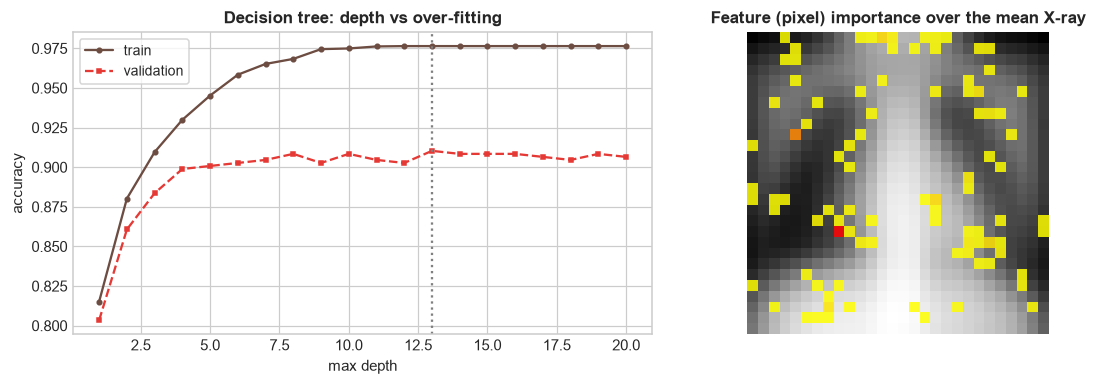

92 pixels utilisés sur 784 ; les 5 premiers concentrent 64% de l'importance :


px(18,8)     0.340
px(9,4)      0.162
px(0,12)     0.048
px(15,17)    0.046
px(19,22)    0.042
dtype: float64

In [2]:
depths = list(range(1, 21))
rows = []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, min_samples_leaf=5, random_state=U.SEED).fit(Xtr, y_train)
    rows.append({"depth": d, "train_acc": accuracy_score(y_train, t.predict(Xtr)), "val_acc": accuracy_score(y_val, t.predict(Xva))})
tree_curve = pd.DataFrame(rows)
best_depth = int(tree_curve.sort_values(["val_acc", "depth"], ascending=[False, True]).iloc[0].depth)
tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=5, random_state=U.SEED).fit(Xtr, y_train)
print(f"Profondeur retenue (validation) : {best_depth} — {tree.get_n_leaves()} feuilles — accuracy val {accuracy_score(y_val, tree.predict(Xva)):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(tree_curve.depth, tree_curve.train_acc, "o-", ms=3, label="train", color=U.COLORS["tree"])
ax[0].plot(tree_curve.depth, tree_curve.val_acc, "s--", ms=3, label="validation", color=U.COLORS["gb"])
ax[0].axvline(best_depth, color="grey", ls=":")
ax[0].set(xlabel="max depth", ylabel="accuracy", title="Decision tree: depth vs over-fitting"); ax[0].legend()

imp = tree.feature_importances_.reshape(28, 28)
ax[1].imshow(X_train.mean(0).reshape(28, 28), cmap="gray")
ax[1].imshow(np.ma.masked_where(imp == 0, imp), cmap="autumn_r", alpha=0.85)
ax[1].set_title("Feature (pixel) importance over the mean X-ray"); ax[1].axis("off")
plt.tight_layout()
U.save_fig(fig, "fig_tree")
plt.show()

top = pd.Series(tree.feature_importances_, index=pixel_names).sort_values(ascending=False)
print(f"{(tree.feature_importances_ > 0).sum()} pixels utilisés sur 784 ; les 5 premiers concentrent {top.head(5).sum():.0%} de l'importance :")
top.head(5).round(3)

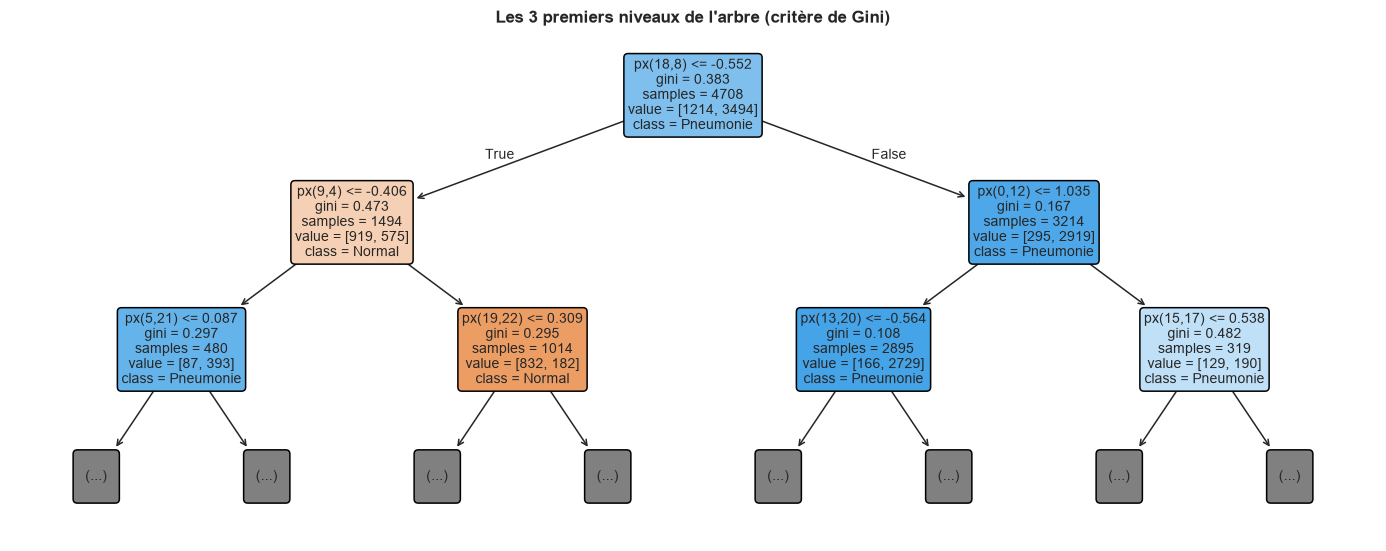

In [3]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree, max_depth=2, feature_names=pixel_names, class_names=U.CLASS_NAMES, filled=True, rounded=True, fontsize=9, impurity=True, ax=ax)
ax.set_title("Les 3 premiers niveaux de l'arbre (critère de Gini)")
plt.show()

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

#### Vérification empirique de la complexité $O(n \cdot m \cdot \text{depth})$

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

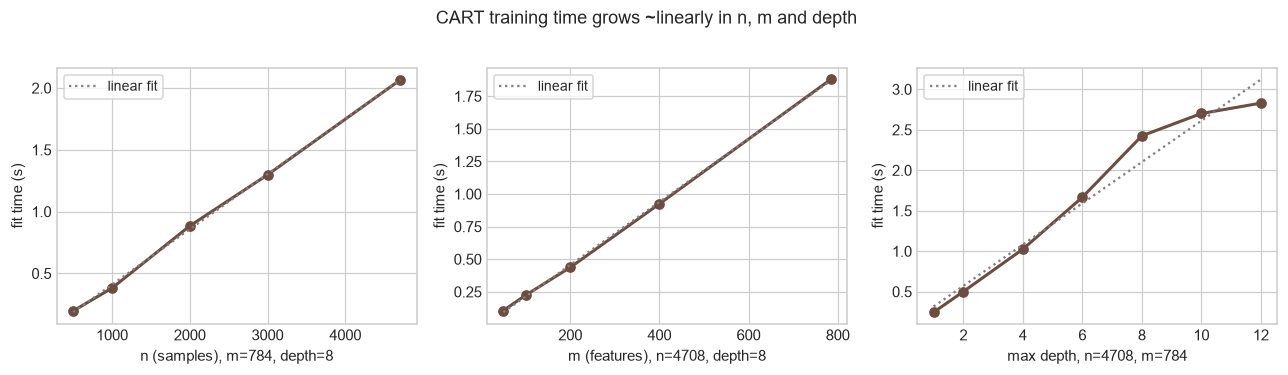

Remarque : en profondeur, la croissance s'infléchit quand les nœuds deviennent purs ou trop petits (l'arbre réel est moins profond que max_depth).


In [4]:
def fit_time(X, y, depth, reps=3):
    best = np.inf
    for _ in range(reps):
        t0 = time.perf_counter()
        DecisionTreeClassifier(max_depth=depth, random_state=U.SEED).fit(X, y)
        best = min(best, time.perf_counter() - t0)
    return best

rng = np.random.default_rng(U.SEED)
ns = [500, 1000, 2000, 3000, 4708]
ms = [50, 100, 200, 400, 784]
ds = [1, 2, 4, 6, 8, 10, 12]
t_n = [fit_time(Xtr[:n], y_train[:n], 8) for n in ns]
t_m = [fit_time(Xtr[:, rng.choice(784, m, replace=False)], y_train, 8) for m in ms]
t_d = [fit_time(Xtr, y_train, d) for d in ds]

fig, ax = plt.subplots(1, 3, figsize=(12, 3.3), sharey=False)
for a, x, t, lab in [(ax[0], ns, t_n, "n (samples), m=784, depth=8"), (ax[1], ms, t_m, "m (features), n=4708, depth=8"),
                     (ax[2], ds, t_d, "max depth, n=4708, m=784")]:
    a.plot(x, t, "o-", color=U.COLORS["tree"], lw=2)
    coef = np.polyfit(x, t, 1); a.plot(x, np.polyval(coef, x), ":", color="grey", label="linear fit")
    a.set(xlabel=lab, ylabel="fit time (s)"); a.legend()
fig.suptitle("CART training time grows ~linearly in n, m and depth", y=1.02)
plt.tight_layout()
U.save_fig(fig, "fig_tree_complexity")
plt.show()
print("Remarque : en profondeur, la croissance s'infléchit quand les nœuds deviennent purs ou trop petits (l'arbre réel est moins profond que max_depth).")

<div style="margin-top:6px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#4facfe,#0006ab);background-size:150% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:1.55rem;font-weight:800;animation:tp4Flow 7s ease-in-out infinite;">🚀 Amélioration par Boosting</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

Le **boosting** construit séquentiellement $F_T(x)=\sum_{t=1}^{T}\eta\,\beta_t\,h_t(x)$ en ajoutant des arbres faibles
qui corrigent les erreurs des précédents :

* **AdaBoost** (Freund & Schapire) : repondère les exemples, $w_i \leftarrow w_i\,e^{\beta_t\,\mathbb{1}[h_t(x_i)\neq y_i]}$
  ⇒ minimise la perte **exponentielle**. ⚠️ Les exemples mal étiquetés reçoivent des poids qui explosent : AdaBoost est
  réputé **sensible au bruit de labels** (point testé en Partie 3).
* **Gradient Boosting** (Friedman) : chaque arbre est ajusté au **gradient négatif** de la perte (log-loss) ; nous
  utilisons la version histogramme de scikit-learn (`HistGradientBoostingClassifier`, même algorithme que LightGBM),
  beaucoup plus rapide sur 784 features. Régularisation : taux d'apprentissage $\eta$, profondeur/feuilles, pénalité L2.

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

AdaBoost : meilleure accuracy val 0.9676 à 186 arbres (179.4s pour 300 arbres)
Gradient Boosting : lr=0.1, max_leaf_nodes=15, 54 itérations → accuracy val 0.9695


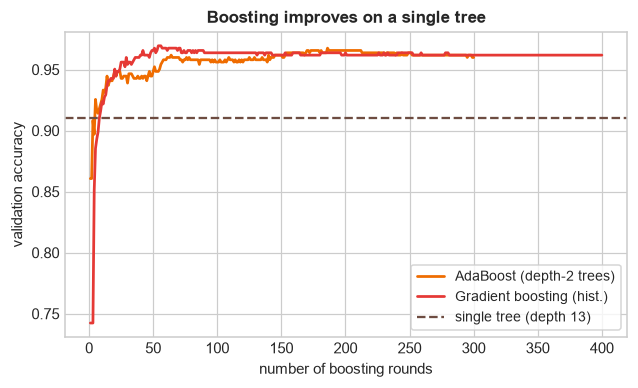

In [5]:
t0 = time.perf_counter()
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), n_estimators=300, learning_rate=0.5, random_state=U.SEED).fit(Xtr, y_train)
t_ada = time.perf_counter() - t0
ada_curve = [accuracy_score(y_val, p) for p in ada.staged_predict(Xva)]

hgb_grid = []
for lr in [0.05, 0.1]:
    for leaves in [15, 31]:
        m = HistGradientBoostingClassifier(learning_rate=lr, max_leaf_nodes=leaves, max_iter=400, early_stopping=False,
                                           l2_regularization=1.0, random_state=U.SEED).fit(Xtr, y_train)
        curve = [accuracy_score(y_val, (p[:, 1] >= 0.5).astype(int)) for p in m.staged_predict_proba(Xva)]
        hgb_grid.append({"learning_rate": lr, "max_leaf_nodes": leaves, "best_iter": int(np.argmax(curve) + 1),
                         "val_acc": max(curve), "curve": curve})
hgb_grid = sorted(hgb_grid, key=lambda r: -r["val_acc"])
hb = hgb_grid[0]
best_ada_n = int(np.argmax(ada_curve) + 1)
print(f"AdaBoost : meilleure accuracy val {max(ada_curve):.4f} à {best_ada_n} arbres ({t_ada:.1f}s pour 300 arbres)")
print(f"Gradient Boosting : lr={hb['learning_rate']}, max_leaf_nodes={hb['max_leaf_nodes']}, {hb['best_iter']} itérations → accuracy val {hb['val_acc']:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(range(1, len(ada_curve) + 1), ada_curve, color=U.COLORS["ada"], lw=1.8, label="AdaBoost (depth-2 trees)")
ax.plot(range(1, len(hb["curve"]) + 1), hb["curve"], color=U.COLORS["gb"], lw=1.8, label="Gradient boosting (hist.)")
ax.axhline(accuracy_score(y_val, tree.predict(Xva)), color=U.COLORS["tree"], ls="--", label=f"single tree (depth {best_depth})")
ax.set(xlabel="number of boosting rounds", ylabel="validation accuracy", title="Boosting improves on a single tree")
ax.legend()
U.save_fig(fig, "fig_boosting")
plt.show()

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), n_estimators=best_ada_n, learning_rate=0.5, random_state=U.SEED).fit(Xtr, y_train)
hgb = HistGradientBoostingClassifier(learning_rate=hb["learning_rate"], max_leaf_nodes=hb["max_leaf_nodes"], max_iter=hb["best_iter"],
                                     early_stopping=False, l2_regularization=1.0, random_state=U.SEED).fit(Xtr, y_train)

<div style="margin-top:6px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#4facfe,#0006ab);background-size:150% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:1.55rem;font-weight:800;animation:tp4Flow 7s ease-in-out infinite;">⚔️ Task 2.2 : Support Vector Machines</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

**SVM linéaire à marge dure.** Pour des données séparables ($y_i\in\{-1,+1\}$), on cherche l'hyperplan $w^\top x+b=0$
de **marge maximale**. La marge (distance entre les deux hyperplans $w^\top x+b=\pm1$) vaut $2/\lVert w\rVert$ :

$$\boxed{\min_{w,b}\ \tfrac12\lVert w\rVert^2 \quad \text{s.c.}\quad y_i(w^\top x_i+b)\ \ge 1\ \ \forall i}$$

Les **vecteurs supports** sont les points qui touchent la marge ($y_i(w^\top x_i+b)=1$) : ce sont les seuls avec un
multiplicateur de Lagrange $\alpha_i>0$, et la solution $w=\sum_i \alpha_i y_i x_i$ ne dépend **que d'eux**.

**Marge souple** (cas linéaire mais non séparable). On autorise des violations $\xi_i \ge 0$ payées au prix $C$ :

$$\boxed{\min_{w,b,\xi}\ \tfrac12\lVert w\rVert^2 + C\sum_{i}\xi_i \quad\text{s.c.}\quad y_i(w^\top x_i+b)\ge 1-\xi_i,\ \ \xi_i\ge0}
\iff \min_{w,b}\ \tfrac12\lVert w\rVert^2 + C\sum_i \max\big(0,\,1-y_i(w^\top x_i+b)\big)$$

$C$ règle le compromis : **$C$ petit** ⇒ marge large, beaucoup de vecteurs supports, forte régularisation (plus tolérant
aux points aberrants / mal étiquetés) ; **$C$ grand** ⇒ marge étroite, on cherche à classer correctement chaque point
d'entraînement (risque de sur-apprentissage, et de « suivre » les labels bruités).

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

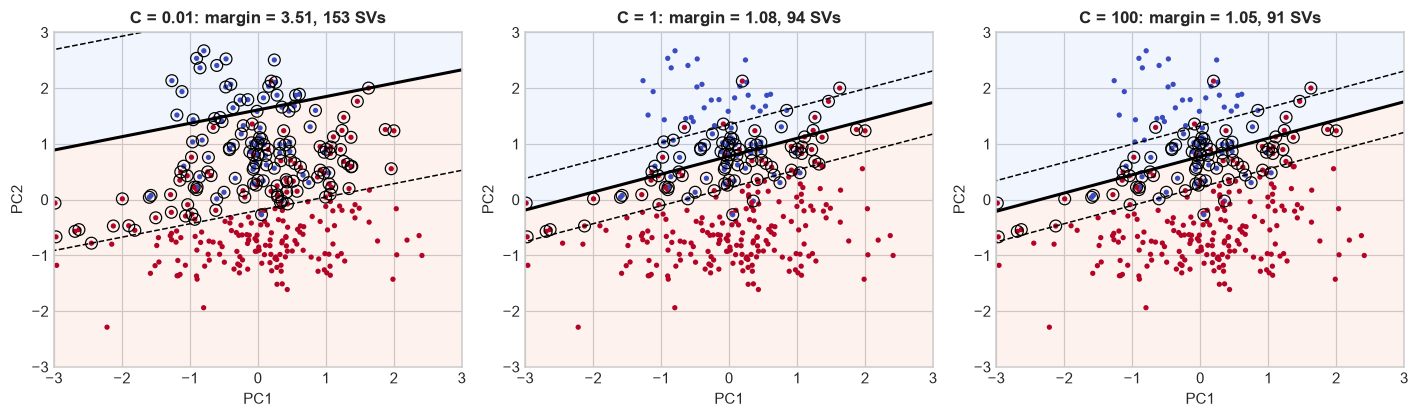

Cercles noirs = vecteurs supports ; trait plein = frontière ; tirets = marge (w·x+b = ±1).


In [6]:
# Illustration 2D : projection PCA de 300 radiographies, SVM linéaire pour trois valeurs de C
pca2 = PCA(n_components=2, random_state=U.SEED).fit(Xtr)
idx = np.random.default_rng(U.SEED).choice(len(Xtr), 300, replace=False)
Z, yz = pca2.transform(Xtr[idx]), y_train[idx]
Z = (Z - Z.mean(0)) / Z.std(0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, C_ in zip(axes, [0.01, 1, 100]):
    svm = SVC(kernel="linear", C=C_).fit(Z, yz)
    xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
    F = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, F > 0, alpha=0.12, cmap="coolwarm")
    ax.contour(xx, yy, F, levels=[-1, 0, 1], colors=["k", "k", "k"], linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    ax.scatter(Z[:, 0], Z[:, 1], c=yz, cmap="coolwarm", s=12, edgecolors="none")
    sv = svm.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors="none", edgecolors="k", linewidths=0.8)
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="PC1", ylabel="PC2",
           title=f"C = {C_}: margin = {2/np.linalg.norm(svm.coef_):.2f}, {len(sv)} SVs")
plt.tight_layout()
U.save_fig(fig, "fig_svm_margin")
plt.show()
print("Cercles noirs = vecteurs supports ; trait plein = frontière ; tirets = marge (w·x+b = ±1).")

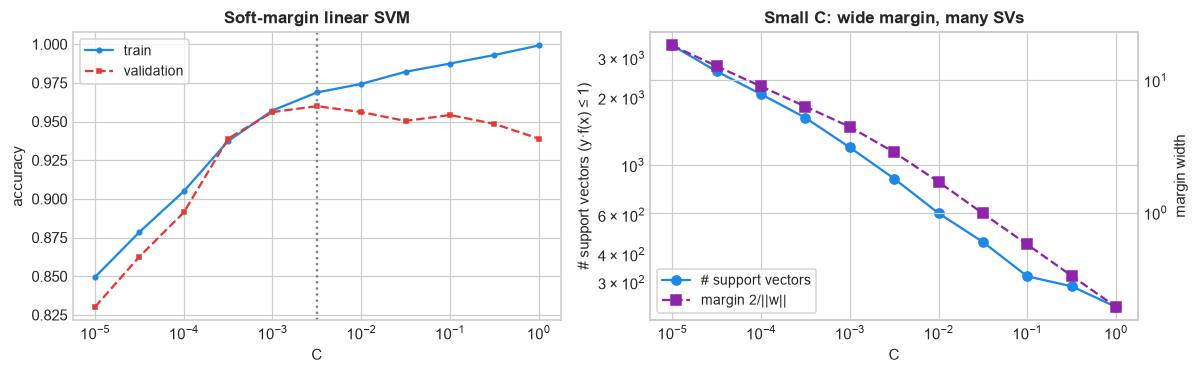

C retenu (validation) : 3.2e-03 — accuracy val 0.9599


,C,val_acc,train_acc,n_support,margin
0,0.0000,0.8302,0.8494,3415,18.2786
1,0.0000,0.8626,0.8785,2619,12.7558
2,0.0001,0.8912,0.9048,2071,8.9724
3,0.0003,0.9389,0.9373,1625,6.3271
4,0.0010,0.9561,0.9571,1199,4.4439
5,0.0032,0.9599,0.9688,870,2.8526
6,0.0100,0.9561,0.9743,610,1.7092
7,0.0316,0.9504,0.9822,454,0.9853
8,0.1000,0.9542,0.9875,319,0.5751
9,0.3162,0.9485,0.9930,288,0.3334


In [7]:
# SVM linéaire à marge souple sur les 784 pixels : effet de C (liblinear, hinge loss)
rows = []
y_pm = 2 * y_train - 1
for C_ in np.logspace(-5, 0, 11):
    with warnings.catch_warnings():   # pour C grand, liblinear n'atteint pas la tolérance : sans effet sur la conclusion
        warnings.simplefilter("ignore", ConvergenceWarning)
        lin = LinearSVC(C=C_, loss="hinge", dual=True, max_iter=50_000, random_state=U.SEED).fit(Xtr, y_train)
    f = lin.decision_function(Xtr)
    rows.append({"C": C_, "val_acc": accuracy_score(y_val, lin.predict(Xva)),
                 "train_acc": accuracy_score(y_train, lin.predict(Xtr)),
                 "n_support": int((y_pm * f <= 1 + 1e-9).sum()), "margin": 2 / np.linalg.norm(lin.coef_)})
lin_curve = pd.DataFrame(rows)
best_C_lin = float(lin_curve.sort_values("val_acc", ascending=False).iloc[0].C)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogx(lin_curve.C, lin_curve.train_acc, "o-", ms=3, label="train", color=U.COLORS["svm_lin"])
ax[0].semilogx(lin_curve.C, lin_curve.val_acc, "s--", ms=3, label="validation", color=U.COLORS["gb"])
ax[0].axvline(best_C_lin, color="grey", ls=":"); ax[0].set(xlabel="C", ylabel="accuracy", title="Soft-margin linear SVM"); ax[0].legend()
ax2 = ax[1].twinx()
ax[1].loglog(lin_curve.C, lin_curve.n_support, "o-", color=U.COLORS["svm_lin"], label="# support vectors")
ax2.loglog(lin_curve.C, lin_curve.margin, "s--", color=U.COLORS["sga"], label="margin 2/||w||")
ax[1].set(xlabel="C", ylabel="# support vectors (y·f(x) ≤ 1)"); ax2.set_ylabel("margin width")
ax[1].set_title("Small C: wide margin, many SVs")
h1, l1 = ax[1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax[1].legend(h1 + h2, l1 + l2, loc="lower left")
plt.tight_layout()
U.save_fig(fig, "fig_svm_C")
plt.show()
lin_svm = LinearSVC(C=best_C_lin, loss="hinge", dual=True, max_iter=50_000, random_state=U.SEED).fit(Xtr, y_train)
print(f"C retenu (validation) : {best_C_lin:.1e} — accuracy val {accuracy_score(y_val, lin_svm.predict(Xva)):.4f}")
lin_curve.round(4)

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

**SVM à noyau (cas non linéaire).** Le dual du SVM ne fait intervenir les données que par des produits scalaires
$x_i^\top x_j$. On les remplace par un **noyau** $K(x,x')=\langle\varphi(x),\varphi(x')\rangle$ : le SVM devient linéaire dans
l'espace $\varphi(\cdot)$ (de grande, voire infinie, dimension) **sans jamais calculer $\varphi$** (*kernel trick*) :

$$\boxed{f(x)=\operatorname{sign}\Big(\sum_{i\in SV}\alpha_i y_i\,K(x_i,x)+b\Big)}\qquad
\boxed{K_{\text{RBF}}(x,x')=\exp\!\big(-\gamma\lVert x-x'\rVert^2\big)}$$

Pour le noyau RBF, le développement en série de $e^{2\gamma x^\top x'}$ montre que $\varphi$ contient **tous les monômes
de tous les degrés** : l'espace implicite est de dimension infinie. $\gamma$ fixe la portée d'influence de chaque vecteur
support (grand $\gamma$ ⇒ frontière très locale). Illustration avec un noyau polynomial explicite
$\varphi(x_1,x_2)=(x_1,x_2,x_1^2+x_2^2)$ : des cercles concentriques deviennent séparables par un plan.

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

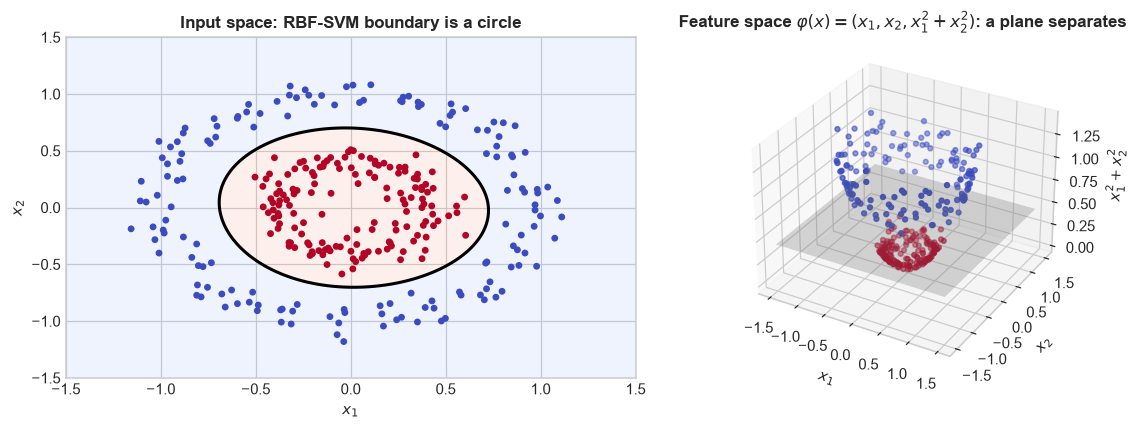

In [8]:
Xc, yc = make_circles(n_samples=300, factor=0.4, noise=0.08, random_state=U.SEED)
svm_c = SVC(kernel="rbf", C=1, gamma=1).fit(Xc, yc)
fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1)
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
F = svm_c.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, F > 0, alpha=0.15, cmap="coolwarm"); ax.contour(xx, yy, F, levels=[0], colors="k", linewidths=2)
ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", s=12)
ax.set(title="Input space: RBF-SVM boundary is a circle", xlabel="$x_1$", ylabel="$x_2$")
ax = fig.add_subplot(1, 2, 2, projection="3d")
r2 = (Xc ** 2).sum(1)
ax.scatter(Xc[:, 0], Xc[:, 1], r2, c=yc, cmap="coolwarm", s=10)
P, Q = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
ax.plot_surface(P, Q, np.full_like(P, 0.45), alpha=0.25, color="grey")
ax.set(title=r"Feature space $\varphi(x)=(x_1,x_2,x_1^2+x_2^2)$: a plane separates", xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_1^2+x_2^2$")
plt.tight_layout()
U.save_fig(fig, "fig_kernel_trick")
plt.show()

Grille (C, γ) évaluée en 61s — meilleur : C=3, γ=0.001 (accuracy val 0.9733)


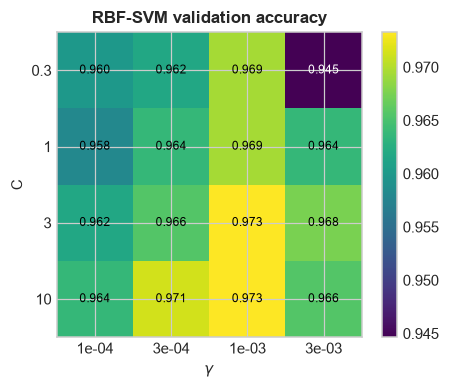

SVM RBF final : 758 vecteurs supports (16% du train), par classe {'Normal': 367, 'Pneumonie': 391}


In [9]:
C_grid, g_grid = [0.3, 1, 3, 10], [1e-4, 3e-4, 1e-3, 3e-3]
acc = np.zeros((len(C_grid), len(g_grid)))
t0 = time.perf_counter()
for i, C_ in enumerate(C_grid):
    for j, g in enumerate(g_grid):
        acc[i, j] = accuracy_score(y_val, SVC(kernel="rbf", C=C_, gamma=g).fit(Xtr, y_train).predict(Xva))
i, j = np.unravel_index(acc.argmax(), acc.shape)
best_C_rbf, best_gamma = C_grid[i], g_grid[j]
print(f"Grille (C, γ) évaluée en {time.perf_counter() - t0:.0f}s — meilleur : C={best_C_rbf}, γ={best_gamma} (accuracy val {acc[i, j]:.4f})")

fig, ax = plt.subplots(figsize=(4.8, 3.6))
im = ax.imshow(acc, cmap="viridis")
ax.set_xticks(range(len(g_grid)), [f"{g:.0e}" for g in g_grid]); ax.set_yticks(range(len(C_grid)), C_grid)
for a in range(len(C_grid)):
    for b in range(len(g_grid)):
        ax.text(b, a, f"{acc[a, b]:.3f}", ha="center", va="center", color="w" if acc[a, b] < acc.max() - 0.02 else "k", fontsize=8)
ax.set(xlabel=r"$\gamma$", ylabel="C", title="RBF-SVM validation accuracy")
plt.colorbar(im, ax=ax, fraction=0.046)
U.save_fig(fig, "fig_svm_rbf_grid")
plt.show()

svm_rbf = SVC(kernel="rbf", C=best_C_rbf, gamma=best_gamma).fit(Xtr, y_train)
print(f"SVM RBF final : {svm_rbf.n_support_.sum()} vecteurs supports ({svm_rbf.n_support_.sum() / len(Xtr):.0%} du train), "
      f"par classe {dict(zip(U.CLASS_NAMES, svm_rbf.n_support_.tolist()))}")

<div style="margin-top:6px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#4facfe,#0006ab);background-size:150% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:1.55rem;font-weight:800;animation:tp4Flow 7s ease-in-out infinite;">🗺️ Task 2.3 : Visualisation des Frontières de Décision</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

<div style="background:linear-gradient(135deg,rgba(142,36,170,.09),rgba(123,31,162,.04));border-left:5px solid #8e24aa;border-radius:12px;padding:4px 20px 10px 20px;margin:8px 0;box-shadow:0 4px 16px rgba(142,36,170,.10);font-family:'Segoe UI',system-ui,sans-serif;line-height:1.6;">
<div style="height:3px;margin:0 -20px 6px -20px;border-radius:3px;background:linear-gradient(90deg,#f0f0f0,#8e24aa,#f0f0f0);background-size:300% 100%;animation:tp4Flow 7s ease-in-out infinite;"></div>

On projette les images sur les **deux premières composantes principales** (PCA, axes de variance maximale de la
covariance $\Sigma=\frac{1}{n-1}\sum_i(x_i-\bar x)(x_i-\bar x)^\top$), puis on entraîne dans ce plan deux modèles
**contrastés** — Régression Logistique et Arbre de Décision — ainsi qu'un SVM RBF comme référence non linéaire.
On affiche $P(\text{Pneumonie}\mid x)$ en couleur et la frontière $P=0{,}5$ en noir.

</div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

Variance expliquée par PC1+PC2 : 52.1%


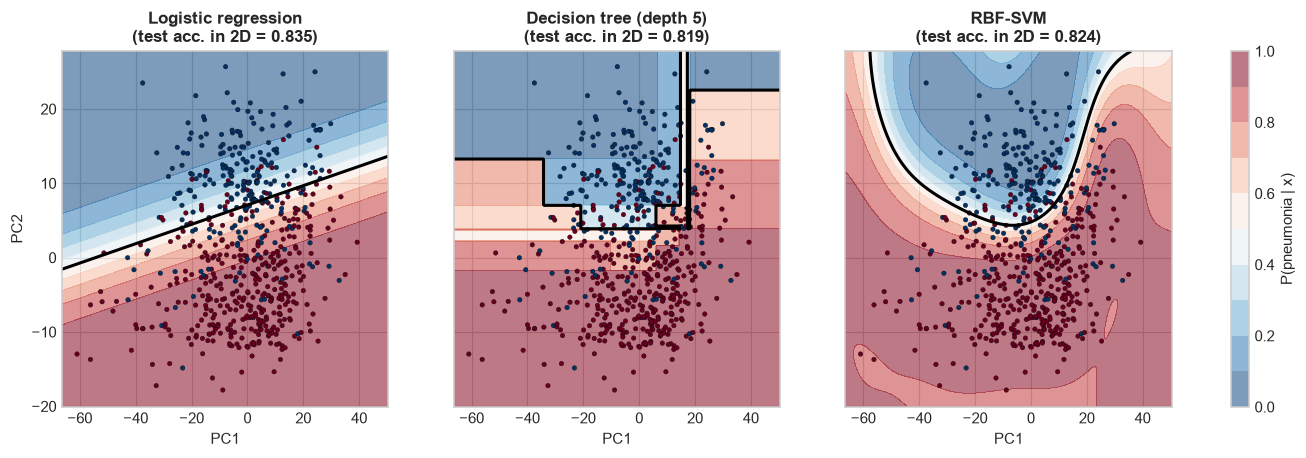

In [10]:
P_tr, P_te = pca2.transform(Xtr), pca2.transform(Xte)
print(f"Variance expliquée par PC1+PC2 : {pca2.explained_variance_ratio_.sum():.1%}")
models_2d = {
    "Logistic regression": LogisticRegression(max_iter=1000).fit(P_tr, y_train),
    "Decision tree (depth 5)": DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=U.SEED).fit(P_tr, y_train),
    # probabilités du SVM obtenues par calibration de Platt (validation croisée interne)
    "RBF-SVM": CalibratedClassifierCV(SVC(kernel="rbf", C=1, gamma="scale"), ensemble=False).fit(P_tr, y_train),
}
lo, hi = np.percentile(P_tr, [1, 99], axis=0)
pad = 0.15 * (hi - lo)
xx, yy = np.meshgrid(np.linspace(lo[0] - pad[0], hi[0] + pad[0], 300), np.linspace(lo[1] - pad[1], hi[1] + pad[1], 300))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, (name, m) in zip(axes, models_2d.items()):
    Pz = m.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    cs = ax.contourf(xx, yy, Pz, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.55)
    ax.contour(xx, yy, Pz, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(P_te[:, 0], P_te[:, 1], c=y_test, cmap="RdBu_r", s=9, edgecolors="k", linewidths=0.2)
    ax.set(title=f"{name}\n(test acc. in 2D = {accuracy_score(y_test, m.predict(P_te)):.3f})", xlabel="PC1",
           xlim=(xx.min(), xx.max()), ylim=(yy.min(), yy.max()))
axes[0].set_ylabel("PC2")
fig.colorbar(cs, ax=axes, fraction=0.02, label="P(pneumonia | x)")
U.save_fig(fig, "fig_boundaries")
plt.show()

<div style="background:rgba(142,36,170,.07);border-left:4px solid #8e24aa;border-radius:10px;padding:12px 16px;margin:6px 0;font-family:'Segoe UI',system-ui,sans-serif;"><b style="color:#8e24aa;">🔎 Explication des différences observées</b><div style="margin-top:6px;line-height:1.55;">
<ul style="margin:4px 0 0 0;">
<li><b>Régression logistique</b> : frontière = <b>droite</b> ($\theta^\top x+b=0$), et les probabilités varient
<b>de façon lisse et monotone</b> perpendiculairement à elle (bandes parallèles). Modèle à fort biais / faible variance.</li>
<li><b>Arbre de décision</b> : chaque nœud teste une seule coordonnée ⇒ frontière en <b>escalier</b>, faite de segments
<b>parallèles aux axes</b>, et des probabilités <b>constantes par morceaux</b> (une valeur par feuille). Il capture des
interactions non linéaires mais produit des régions isolées (variance élevée, instabilité).</li>
<li><b>SVM RBF</b> : frontière <b>courbe et lisse</b>, intermédiaire entre les deux.</li>
<li>En 2D, seule une partie de la variance est conservée : les accuracies sont inférieures à celles des modèles en 784D.</li>
</ul></div></div>

<div style="margin-top:6px;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#4facfe,#0006ab);background-size:150% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:1.55rem;font-weight:800;animation:tp4Flow 7s ease-in-out infinite;">🏁 Bilan de la Phase II (test)</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>

In [11]:
phase2 = {
    f"Decision tree (depth {best_depth})": (tree.predict(Xte), tree.predict_proba(Xte)[:, 1]),
    f"AdaBoost ({best_ada_n} trees)": (ada.predict(Xte), ada.predict_proba(Xte)[:, 1]),
    "Gradient boosting (hist.)": (hgb.predict(Xte), hgb.predict_proba(Xte)[:, 1]),
    "Linear SVM": (lin_svm.predict(Xte), lin_svm.decision_function(Xte)),
    "RBF-SVM": (svm_rbf.predict(Xte), svm_rbf.decision_function(Xte)),
}
res2 = pd.DataFrame([{"Model": k, **U.binary_metrics(y_test, p, s)} for k, (p, s) in phase2.items()])
U.save_results("phase2_test.csv", res2)
U.save_results("phase2_params.json", {
    "tree_depth": best_depth, "ada_n_estimators": best_ada_n,
    "hgb_learning_rate": hb["learning_rate"], "hgb_max_leaf_nodes": hb["max_leaf_nodes"], "hgb_max_iter": hb["best_iter"],
    "linsvm_C": best_C_lin, "rbf_C": best_C_rbf, "rbf_gamma": best_gamma})
res2.set_index("Model")[["accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "ap"]].round(3)

,accuracy,precision,recall,specificity,f1,roc_auc,ap
Model,,,,,,,
Decision tree (depth 13),0.804,0.790,0.936,0.585,0.857,0.747,0.775
AdaBoost (186 trees),0.840,0.806,0.979,0.607,0.884,0.931,0.934
Gradient boosting (hist.),0.830,0.800,0.972,0.594,0.877,0.938,0.953
Linear SVM,0.864,0.831,0.982,0.667,0.900,0.925,0.921
RBF-SVM,0.857,0.818,0.992,0.632,0.897,0.947,0.961


<div style="text-align:center;padding:18px 0;"><span style="display:inline-block;background:linear-gradient(90deg,#ffffff,#87ceeb,#1e90ff,#0047ab);background-size:300% 100%;-webkit-background-clip:text;background-clip:text;color:transparent;-webkit-text-fill-color:transparent;font-family:'Montserrat','Segoe UI',sans-serif;font-size:34px;font-weight:900;animation:tp4Flow 7s ease-in-out infinite;padding:14px 30px;border:2px solid rgba(30,144,255,.5);border-radius:12px;animation:tp4Flow 5s ease-in-out infinite,tp4Glow 3s ease-in-out infinite;">Merci de nous avoir écouté pour cette seconde partie !</span></div>
<style>@keyframes tp4Flow{0%,100%{background-position:0% 50%}50%{background-position:100% 50%}}@keyframes tp4Glow{0%,100%{filter:brightness(1)}50%{filter:brightness(1.18)}}</style>